# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [39]:
# Add code here 🔧
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("airbnb_listings.csv")

## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



In [41]:
# Add code here 🔧
#Checking which column I should do
df.select_dtypes(include=np.number).skew()


,0
id,-0.534077
scrape_id,0.000000
host_listings_count,6.877950
host_total_listings_count,7.958853
latitude,0.505016
longitude,-0.811354
accommodates,2.046847
bathrooms,4.485494
bedrooms,1.923699
beds,1.725330


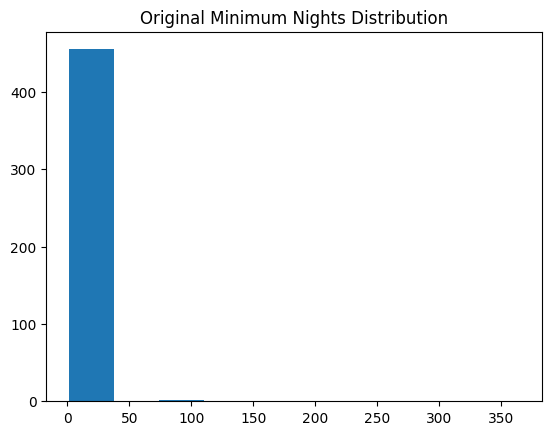

In [42]:
#Plotting a histogram
plt.hist(df["minimum_nights"])
plt.title("Original Minimum Nights Distribution")
plt.show()

In [43]:
#Log transformation
df["minimum_nights_log"] = np.log(df["minimum_nights"] + 1)


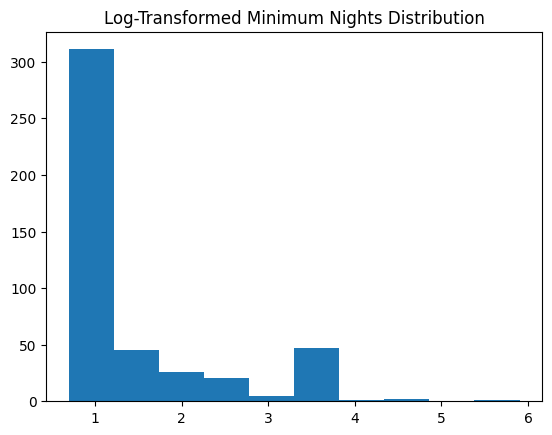

In [44]:
#Plotting again
plt.hist(df["minimum_nights_log"])
plt.title("Log-Transformed Minimum Nights Distribution")
plt.show()



### ✍️ Your Response: 🔧
1. I examined the minimum_nights column.

2. I did a log transformation because it seemed that the column was very highly right-skewed Thus, log transformation can help reduce the extreme values.

3. It helped make the data more balanced and easier to analyze. By reducing the impact of extreme outliers and making patterns easier to see the transformation makes the data much more useful for stakeholders to understand.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [45]:
df.select_dtypes(include=np.number).describe()

,id,scrape_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,minimum_nights_log
count,4.590000e+02,4.590000e+02,459.000000,459.000000,459.000000,459.000000,459.000000,419.000000,453.000000,419.000000,...,391.000000,391.000000,0.0,459.000000,459.000000,459.000000,459.000000,459.0,391.000000,459.000000
mean,8.055481e+17,2.025080e+13,31.572985,52.172113,42.658694,-73.776369,3.448802,1.210024,1.600442,1.789976,...,4.656087,4.718414,NaN,0.228758,6.742919,4.779956,1.962963,0.0,1.986982,1.352748
std,5.352960e+17,0.000000e+00,158.860381,308.399586,0.010116,0.018573,2.465282,0.601071,1.111763,1.203581,...,0.397570,0.384653,NaN,0.420491,6.381206,5.874372,3.851606,0.0,1.946644,0.947261
min,2.992450e+06,2.025080e+13,1.000000,1.000000,42.630660,-73.876490,1.000000,0.000000,0.000000,0.000000,...,2.500000,1.000000,NaN,0.000000,1.000000,0.000000,0.000000,0.0,0.030000,0.693147
25%,5.403460e+07,2.025080e+13,2.000000,2.000000,42.652590,-73.788709,2.000000,1.000000,1.000000,1.000000,...,4.500000,4.660000,NaN,0.000000,1.000000,1.000000,0.000000,0.0,0.590000,0.693147
50%,9.382804e+17,2.025080e+13,5.000000,6.000000,42.657921,-73.773670,2.000000,1.000000,1.000000,1.000000,...,4.800000,4.820000,NaN,0.000000,3.000000,2.000000,0.000000,0.0,1.350000,1.098612
75%,1.264937e+18,2.025080e+13,15.000000,17.000000,42.665027,-73.763310,4.000000,1.000000,2.000000,2.000000,...,4.930000,4.950000,NaN,0.000000,12.000000,6.000000,1.500000,0.0,2.915000,1.386294
max,1.479181e+18,2.025080e+13,1258.000000,2648.000000,42.714900,-73.738250,16.000000,7.000000,8.000000,8.000000,...,5.000000,5.000000,NaN,1.000000,21.000000,21.000000,13.000000,0.0,11.480000,5.902633


In [46]:
df[["price", "minimum_nights"]].describe()


,price,minimum_nights
count,459.000000,459.000000
mean,116.104575,6.732026
std,96.346706,19.922231
min,24.000000,1.000000
25%,73.000000,1.000000
50%,95.000000,2.000000
75%,121.000000,3.000000
max,1050.000000,365.000000


In [47]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale
minmax = MinMaxScaler()
df["price_minmax"] = minmax.fit_transform(df[["price"]])


In [48]:
# Z-score scale
standard = StandardScaler()
df["minimum_nights_zscore"] = standard.fit_transform(df[["minimum_nights"]])

In [49]:
#Checking the new columns were added
df[["price", "price_minmax", "minimum_nights", "minimum_nights_zscore"]].head()


,price,price_minmax,minimum_nights,minimum_nights_zscore
0,70.0,0.044834,28,1.068715
1,104.0,0.077973,2,-0.237784
2,75.0,0.049708,2,-0.237784
3,101.0,0.075049,2,-0.237784
4,110.0,0.083821,1,-0.288034


### ✍️ Your Response: 🔧
1. I scaled price using the min-max scale and I did minimum_nights using the z-score standardization. I picked these because they have very different value ranges and are important features.

2. They will be more useful when doing things like comparing listings or bulidng models that use both features at the same time.

3. People like data analysits at Airbnb would benefit from this as it helps build more accurate models by putting both features on a comparable scale.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [57]:
# Add code here 🔧
df["number_of_reviews"].describe()


,number_of_reviews
count,459.000000
mean,58.644880
std,109.379444
min,0.000000
25%,2.000000
50%,19.000000
75%,65.000000
max,948.000000


In [58]:
df["review_level"] = pd.qcut(df["number_of_reviews"],3,labels=["Low", "Medium", "High"])


In [59]:
df[["number_of_reviews", "review_level"]].head()


,number_of_reviews,review_level
0,9,Medium
1,310,High
2,371,High
3,332,High
4,621,High


### ✍️ Your Response: 🔧
1. I grouped number_of_reviews into 3 different categories including low, medium, and high.

2. Having a grouped view can be easier to quickly understand instead of having to analyze each review. This simplifies comparisons and decision making for stakeholders.

3. This would help the marketing team, they could easily target listings with low review activity for campaigns and so much more.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [60]:
# Add code here 🔧
#First column
df["price_per_min_night"] = df["price"] / df["minimum_nights"]


In [61]:
#Second column
df["long_term_flag"] = df["minimum_nights"] >= 30


In [62]:
#Checking they are added
df[["price", "minimum_nights", "price_per_min_night", "long_term_flag"]].head()


,price,minimum_nights,price_per_min_night,long_term_flag
0,70.0,28,2.5,False
1,104.0,2,52.0,False
2,75.0,2,37.5,False
3,101.0,2,50.5,False
4,110.0,1,110.0,False


### ✍️ Your Response: 🔧 🔧
1. I created price_per_min_ night which is price divided by minimum_nights. And I made long_term_flag which is true if minimum_nights is 30 or more.

2. Many people could use these new columns. For example, hosts, Airbnb managers, and pricing analysts can all find this useful.

3. Price_per_min_night can help someone evaluate how much profit a host can expect per stay or long-term_flag can help find listings that are designed for longer stays which could aid in marketing efforts.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [63]:
# Add code here 🔧
df["room_type"].value_counts()


,count
room_type,
Entire home/apt,336
Private room,123


In [64]:
room_dummies = pd.get_dummies(df["room_type"], prefix="room")


In [65]:
#Adding to the dataset
df = pd.concat([df, room_dummies], axis=1)


In [66]:
df[["room_type", "room_Entire home/apt", "room_Private room"]].head()


,room_type,room_Entire home/apt,room_Private room
0,Entire home/apt,True,False
1,Entire home/apt,True,False
2,Entire home/apt,True,False
3,Entire home/apt,True,False
4,Entire home/apt,True,False


### ✍️ Your Response: 🔧
1. I encoded room_type because it was categorical and cannot be used directly in predictive models. It is also super important for things like pricing and booking.

2. I used one-hot encoding because room types do not have a natural order so doing this converts each one into its own numeric column.

3. This can help pricing models when trying to predict pricing rates. It can also help business reports and dashboards by comparing performance between entire homes or just private rooms much more clearly.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [67]:
# export csv here 🔧
df.to_csv("cleaned_airbnb_data_7.csv", index=False)


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The most important felt like it was scaling the numeric variables. Seeing how much price and minimum nights needed to be adjusted so they could be on a similar scale really showed how raw numbers can distort comparisons.

2. I think that the grouped review level and long-term flag stay would prove to be the most useful ovreall. As mentioned, a host can quickly see if a listings falls into low or high review category. Or a city planner can see how many listings are extended stays for their refrence.

3. I would include filters for the data so users could easily see patterns in the data and help identify high-performing listings and pricing trends. Prior to this I would ensure all neccessary columns that have high correlation are standardized and remove any unneccesary columns.

4. This assignment supports my learning outcomes by helping me use exploritory data techniques to understand patterns in the listings. It also helps me evaluate preformance and prepare data in a way that promotes meaningful decision making.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [54]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_07_data_transformation.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_y